<span style="color:hotpink;font-weight: bold; font-size: 20px;">1st Installing Necessary Libraries </span>

In [ ]:
!pip install PyMuPDF pandas openpyxl
!pip install langchain
!pip install langchain-community
!pip install openai
!pip install pandas openpyxl
!pip install scipy scikit-learn
!pip install seaborn
!pip install fitz


<span style="color:hotpink;font-weight: bold; font-size: 20px;">2nd Importing Key Libraries</span>

In [ ]:
import fitz
import pandas as pd
import numpy as np
import re
import copy
from openai import OpenAI
import openai
import json
import time
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Function to extract paragraphs from PDF</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Function to save paragraphs to an Excel file</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Extract and save paragraphs from a PDF</span>

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Read the Human annotated exel file </span>

In [ ]:
df_H = pd.read_excel('/Users/saraalyahya/Dissertation ✅/data/UB.xlsx', engine='openpyxl')

print(df_H.head())

   Paragraph Number                                     Paragraph Text  \
0                 1  1-877-FACTSET www.callstreet.com Total Pages: ...   
1                 2  06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...   
2                 3  Uber Technologies, Inc. (UBER) Q2 2024 Earning...   
3                 4                   1-877-FACTSET www.callstreet.com   
4                 5    2 Copyright © 2001-2024 FactSet CallStreet, LLC   

  Human Classification  
0                    R  
1                    R  
2                    R  
3                    R  
4                    R  


In [ ]:
num_rows = df_H.shape[0]
print(f"Number of rows: {num_rows}")

Number of rows: 1133


<span style="color:orange;font-weight: bold; font-size: 20px;">Relevance Classification: Human vs. LLM [Binary] </span>

In [ ]:
# Convert multi-class sentiment labels to binary relevance
df_H["Relevance"] = df_H["Human Classification"].apply(lambda x: "Relevant" if x in [-2, -1, 0, +1, +2] else "Irrelevant")

In [ ]:
df_H.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance
0,1,1-877-FACTSET www.callstreet.com Total Pages: ...,R,Irrelevant
1,2,"06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...",R,Irrelevant
2,3,"Uber Technologies, Inc. (UBER) Q2 2024 Earning...",R,Irrelevant
3,4,1-877-FACTSET www.callstreet.com,R,Irrelevant
4,5,"2 Copyright © 2001-2024 FactSet CallStreet, LLC",R,Irrelevant


In [ ]:
# Stratified sampling: 10 relevant, 10 irrelevant
sample_relevant = df_H[df_H["Relevance"] == "Relevant"].sample(10, random_state=99)
sample_irrelevant = df_H[df_H["Relevance"] == "Irrelevant"].sample(10, random_state=99) # 99 so that each time i re-run the code it gives me the same 10 samples
df_demo = pd.concat([sample_relevant, sample_irrelevant])

<span style="color:hotpink;font-weight: bold; font-size: 20px;">----Open AI</span>

In [ ]:
df_Empty = pd.read_excel('/Users/saraalyahya/Dissertation ✅/data/UB empty.xlsx', engine='openpyxl')

print(df_Empty.head())

   Paragraph Number                                     Paragraph Text  \
0                 1  1-877-FACTSET www.callstreet.com Total Pages: ...   
1                 2  06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...   
2                 3  Uber Technologies, Inc. (UBER) Q2 2024 Earning...   
3                 4                   1-877-FACTSET www.callstreet.com   
4                 5    2 Copyright © 2001-2024 FactSet CallStreet, LLC   

   Human Classification  
0                   NaN  
1                   NaN  
2                   NaN  
3                   NaN  
4                   NaN  


In [ ]:
num_rows = len(df_Empty)
print(f"Number of rows: {num_rows}")

Number of rows: 1133


In [ ]:
client = OpenAI(api_key="", base_url="") # I've removed the api key since it's the companies'

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Binary Prompt</span>

In [ ]:
def build_binary_relevance_prompt(text, demo_df):
    examples = ""
    for _, row in demo_df.iterrows():
        examples += f"Sentence: {row['Paragraph Text'].strip()}\nLabel: {row['Relevance']}\n\n"

    prompt = (
        "You are a financial assistant that classifies text as either Relevant or Irrelevant to financial sentiment.\n"
        "Here are some examples labeled by a human:\n\n"
        f"{examples}"
        "Now classify the following sentence.\n"
        f"Sentence: {text.strip()}\nLabel:"
    )
    return prompt


In [ ]:
def classify_relevance_llm(row, demo_df):
    prompt_text = build_binary_relevance_prompt(row["Paragraph Text"], demo_df)

    try:
        response = client.chat.completions.create(
            # model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You classify financial text as Relevant or Irrelevant."},
                {"role": "user", "content": prompt_text}
            ],
            max_tokens=3,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
df_llm_binary = pd.read_excel("/Users/saraalyahya/Dissertation ✅/data/UB empty.xlsx")

start_time = time.time()  # Start the timer

df_llm_binary["LLM Relevance"] = df_llm_binary.apply(lambda row: classify_relevance_llm(row, df_demo), axis=1)


end_time = time.time()  # End the timer

elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.2f} seconds")


Time taken: 4901.13 seconds


In [ ]:
df_llm_binary.head(10)

,Paragraph Number,Paragraph Text,Human Classification,LLM Relevance
0,1,1-877-FACTSET www.callstreet.com Total Pages: ...,NaN,Label: Ir
1,2,"06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...",NaN,Label: Ir
2,3,"Uber Technologies, Inc. (UBER) Q2 2024 Earning...",NaN,Label: Ir
3,4,1-877-FACTSET www.callstreet.com,NaN,Label: Ir
4,5,"2 Copyright © 2001-2024 FactSet CallStreet, LLC",NaN,Label: Ir
5,6,"Deepa Subramanian Vice President, Investor Rel...",NaN,Label: Ir
6,7,"Brian Nowak Analyst, Morgan Stanley & Co. LLC ...",NaN,Label: Ir
7,8,"Operator: Hello, and welcome to the Uber Q2 20...",NaN,Label: Ir
8,9,I would now like to turn the conference over t...,NaN,Label: Ir
9,10,"Deepa Subramanian Vice President, Investor Rel...",NaN,Label: Ir


<span style="color:hotpink;font-weight: bold; font-size: 20px;">compare llm with human </span>

In [ ]:
df_H.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance
0,1,1-877-FACTSET www.callstreet.com Total Pages: ...,R,Irrelevant
1,2,"06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...",R,Irrelevant
2,3,"Uber Technologies, Inc. (UBER) Q2 2024 Earning...",R,Irrelevant
3,4,1-877-FACTSET www.callstreet.com,R,Irrelevant
4,5,"2 Copyright © 2001-2024 FactSet CallStreet, LLC",R,Irrelevant


In [ ]:
# Merge on Paragraph Number
df_B_merge= df_H.merge(df_llm_binary[["Paragraph Number", "LLM Relevance"]], on="Paragraph Number", how="inner")


In [ ]:
df_B_merge.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Relevance
0,1,1-877-FACTSET www.callstreet.com Total Pages: ...,R,Irrelevant,Label: Ir
1,2,"06-Aug-2024 Uber Technologies, Inc. (UBER) Q2 ...",R,Irrelevant,Label: Ir
2,3,"Uber Technologies, Inc. (UBER) Q2 2024 Earning...",R,Irrelevant,Label: Ir
3,4,1-877-FACTSET www.callstreet.com,R,Irrelevant,Label: Ir
4,5,"2 Copyright © 2001-2024 FactSet CallStreet, LLC",R,Irrelevant,Label: Ir


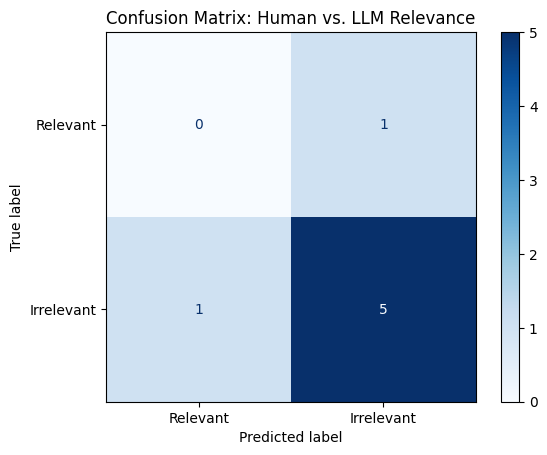

In [ ]:
y_true = df_B_merge["Relevance"]
y_pred = df_B_merge["LLM Relevance"]

labels = ["Relevant", "Irrelevant"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix: Human vs. LLM Relevance")
plt.show()


- the LLM correctly identified 727 sentences as Relevant, matching human judgment (True Positives)

- the LLM correctly identified 176 sentences as Irrelevant (True Negatives)

- the LLM incorrectly labeled 224 irrelevant sentences as Relevant (False Positives)

- the LLM missed 6 relevant sentences, calling them Irrelevant (False Negatives)

In [ ]:
# Clean string labels
y_true = [label.replace("Label: ", "").strip() for label in y_true]
y_pred = [label.replace("Label: ", "").strip() for label in y_pred]

In [ ]:
print("Unique y_true labels:", set(y_true))
print("Unique y_pred labels:", set(y_pred))

Unique y_true labels: {'Relevant', 'Irrelevant'}
Unique y_pred labels: {'Ir', 'Irrelevant', 'The sentence discusses', 'The label for', 'Relevant', 'The sentence "', 'The sentence is'}


In [ ]:
#print(classification_report(y_true, y_pred, target_names=["Relevant", "Irrelevant"]))
print(classification_report(y_true,y_pred,labels=["Relevant", "Irrelevant"],target_names=["Relevant", "Irrelevant"], zero_division=0 ))

              precision    recall  f1-score   support

    Relevant       0.96      0.92      0.94       733
  Irrelevant       0.83      0.01      0.02       400

   micro avg       0.96      0.60      0.74      1133
   macro avg       0.90      0.46      0.48      1133
weighted avg       0.92      0.60      0.62      1133



- 80% of the LLM's predictions match the human annotations

Relevant Class:


- Precision: 0.97 → When the LLM says a sentence is relevant, it's correct 97% of the time

- Recall: 0.44 → It captures 44% of all human-labeled relevant sentences

- F1 Score: 0.60 → Moderate performance; the LLM is precise but misses many relevant sentences

Irrelevant Class:

- Precision: 0.76 → When the LLM says a sentence is irrelevant, it's correct 76% of the time

- Recall: 0.99 → It catches almost all irrelevant sentences

- F1 Score: 0.86 → Strong performance; the LLM is confident and accurate here

<span style="color:hotpink;font-weight: bold; font-size: 20px;">Ive added this code so i can do a text comparison (manually) for my paper</span>

In [ ]:
# False Positives
fp = df_B_merge[(df_B_merge["Relevance"] == "Irrelevant") & (df_B_merge["LLM Relevance"] == "Relevant")]

# False Negatives
fn = df_B_merge[(df_B_merge["Relevance"] == "Relevant") & (df_B_merge["LLM Relevance"] == "Irrelevant")]

# print(fp)
# print(fn)

In [ ]:
fp.to_excel("overall_Binary_fp.xlsx")

In [ ]:
fn.to_excel("overall_Binary_fn.xlsx")

<span style="color:orange;font-weight: bold; font-size: 20px;">Sentiment Classification: Human vs. LLM [Ordinal]</span>

In [ ]:
# Only keep relevant sentiment classes (-2 to +2)
df_Relv = df_H[df_H["Human Classification"].isin([-2, -1, 0, 1, 2])]

In [ ]:
df_Relv.head(2)

,Paragraph Number,Paragraph Text,Human Classification,Relevance
16,17,Dara Khosrowshahi Chief Executive Officer & Di...,2,Relevant
17,18,These are super strong results that we're prou...,2,Relevant


In [ ]:
# Take 5 examples per class
example_dict = {}
for label in [-2, -1, 0, 1, 2]:
    samples = df_Relv[df_Relv["Human Classification"] == label].sample(5, random_state=99)
    example_dict[label] = samples["Paragraph Text"].tolist()


<span style="color:hotpink;font-weight: bold; font-size: 20px;">Prompt</span>

In [ ]:
def build_few_shot_prompt(text, example_dict):
    label_description = {
        -2: "Strongly Negative",
        -1: "Negative",
        0: "Neutral",
        1: "Positive",
        2: "Strongly Positive"
    }

    example_block = "Here are example paragraphs labeled by a human annotator:\n\n"
    for label, texts in example_dict.items():
        for t in texts:
            example_block += f"Sentence: {t.strip()}\nLabel: {label} ({label_description[label]})\n\n"

    classification_prompt = (
        f"{example_block}"
        "Now classify the sentiment of the following paragraph using one of these exact labels: -2, -1, 0, +1, +2.\n"
        "-2 = Strongly Negative\n"
        "-1 = Negative\n"
        " 0 = Neutral\n"
        "+1 = Positive\n"
        "+2 = Strongly Positive\n\n"
        "**Important Rules:**\n"
        "- Only return the numeric label: -2, -1, 0, +1, or +2.\n"
        "- Do not explain.\n\n"
        f"Paragraph: {text.strip()}\nLabel:"
    )

    return classification_prompt


In [ ]:
def classify_ordinal_sentiment(row, example_dict):
    prompt = build_few_shot_prompt(row["Paragraph Text"], example_dict)

    try:
        response = client.chat.completions.create(
            #model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a financial sentiment classifier. Use only human-labeled examples to make consistent predictions."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=5,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
def classify_ordinal_sentiment(row, example_dict):
    prompt = build_few_shot_prompt(row["Paragraph Text"], example_dict)

    try:
        response = client.chat.completions.create(
            #model="gpt-3.5-turbo",
            model="deepseek-chat",
            messages=[
                {"role": "system", "content": "You are a financial sentiment classifier. Use only human-labeled examples to make consistent predictions."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=5,
            temperature=1.5
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"


In [ ]:
###### takes aroud 28 mins

In [ ]:
start_time = time.time()  # Start the timer

df_Empty["LLM Sentiment"] = df_Empty.apply(lambda row: classify_ordinal_sentiment(row, example_dict), axis=1)


end_time = time.time()  # End the timer

elapsed_time = end_time - start_time
print(f"Time taken: {elapsed_time:.2f} seconds")

Time taken: 4290.85 seconds


<span style="color:hotpink;font-weight: bold; font-size: 20px;">compare llm with human </span>

In [ ]:
df_O_merge = df_Relv.merge(df_Empty[["Paragraph Number", "LLM Sentiment"]], on="Paragraph Number", how="inner")

In [ ]:
df_O_merge.head(10)

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Sentiment
0,17,Dara Khosrowshahi Chief Executive Officer & Di...,2,Relevant,+2
1,18,These are super strong results that we're prou...,2,Relevant,+2
2,19,"First, the strength of the consumer and how Ub...",2,Relevant,+2
3,20,Where the current macroeconomic fears material...,1,Relevant,+1
4,21,"In fact, in Q2, the number of first-time consu...",1,Relevant,+2
5,22,We'll continue to drive consistent top line gr...,1,Relevant,2
6,23,"Second, autonomous. Put simply, Uber is unique...",0,Relevant,1
7,24,We also know that a key factor in AV commercia...,0,Relevant,1
8,27,Let's all say that Uber will be an indispensab...,1,Relevant,+1
9,30,"Brian Nowak Analyst, Morgan Stanley & Co. LLC ...",0,Relevant,0


In [ ]:
num_rows = len(df_O_merge)
print(f"Number of rows: {num_rows}")

Number of rows: 733


In [ ]:
# to count total rows before dropping
total_rows = len(df_O_merge)

# to count how many rows are missing either in the human or LLM label
rows_with_missing = df_O_merge[["Human Classification", "LLM Sentiment"]].isna().any(axis=1).sum()

print(f"Total rows: {total_rows}")
print(f"Rows with missing values: {rows_with_missing}")
print(f"Rows remaining after drop: {total_rows - rows_with_missing}")


Total rows: 733
Rows with missing values: 0
Rows remaining after drop: 733


In [ ]:
# to mack sure it's integers

In [ ]:
df_O_merge["Human Classification"] = df_O_merge["Human Classification"].astype(int)
df_O_merge["LLM Sentiment"] = df_O_merge["LLM Sentiment"].astype(int)

In [ ]:
df_O_merge.head()

,Paragraph Number,Paragraph Text,Human Classification,Relevance,LLM Sentiment
0,17,Dara Khosrowshahi Chief Executive Officer & Di...,2,Relevant,2
1,18,These are super strong results that we're prou...,2,Relevant,2
2,19,"First, the strength of the consumer and how Ub...",2,Relevant,2
3,20,Where the current macroeconomic fears material...,1,Relevant,1
4,21,"In fact, in Q2, the number of first-time consu...",1,Relevant,2


### Evaluation

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 1: Exact Match Accuracy </span>

In [ ]:
# to extract the true and predicted labels
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

def exact_match_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()


In [ ]:
# to calculate accuracy
exact_accuracy = exact_match_accuracy(y_true, y_pred)

# to display result
print(f" Exact Match Accuracy (excluding 'R'): {exact_accuracy:.2%}") # to convert it to a percentage and show 2 decimals


 Exact Match Accuracy (excluding 'R'): 56.62%


In [ ]:
#this means that just below half the cases, LLM’s sentiment prediction matched my human label exactly

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 2: MAE </span>

In [ ]:
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")


Mean Absolute Error (MAE): 0.60


In [ ]:
total_rows = len(df_O_merge)

print(f"Total rows: {total_rows}")

Total rows: 733


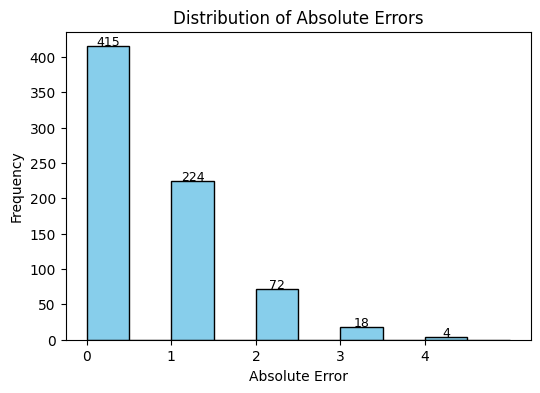

In [ ]:
errors = abs(y_true - y_pred)

# Create bins
bins = np.arange(0, max(errors)+1.5, 0.5)

# ✅ Create the figure first
plt.figure(figsize=(6, 4))

# Plot the histogram and capture the counts and bin edges
counts, bin_edges, patches = plt.hist(errors, bins=bins, edgecolor='black', color='skyblue')

# Add labels
for count, edge in zip(counts, bin_edges[:-1]):
    if count > 0:
        plt.text(edge + 0.25, count + 1, str(int(count)), ha='center', fontsize=9)

# Plot settings
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.xticks(np.arange(0, max(errors)+1, 1))
plt.show()


- this chart shows how wrong the AI was compared to human labels

- each bar tells us how many times the AI was off by a certain amount

What each bar means:

- 0: How many times AI was exactly right (where it predicted the same as the human) → 375 times

- 1: AI was close, but off by 1 (for example: human's annotation was 0, it said +1) → 259 times

- 2: AI was moderately off (for example: human's annotation was -1, it said +1) → 73 times

- 3: AI was very off (for example: human's annotation was +2, it said -1) → 22 times

- 4: AI was extremely off (for example: human's annotation was -2, it said +2) → 4 times

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 3: Spearman Rank Correlation </span>

In [ ]:
spearman_corr, _ = spearmanr(y_true, y_pred)
print(f"Spearman Rank Correlation: {spearman_corr:.2f}")


Spearman Rank Correlation: 0.62


- this means there's a moderate positive relationship between the AI's predictions and human annotations — when human annotations go up, the AI's prediction generally goes up too, but not consistently

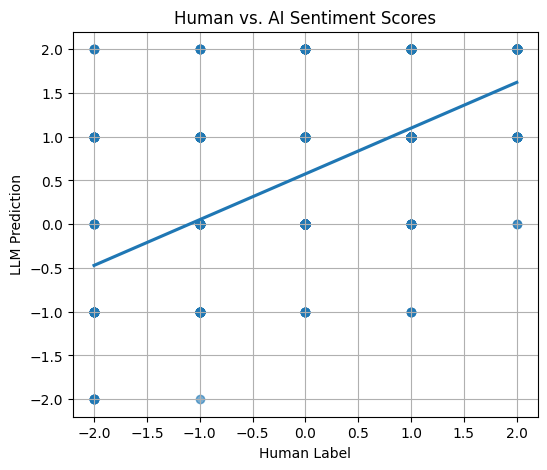

In [ ]:
# make sure y_true and y_pred are defined
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

# create the scatter + trend line plot
plt.figure(figsize=(6, 5))
sns.regplot(x=y_true, y=y_pred, ci=None, scatter_kws={'alpha': 0.6})
plt.title("Human vs. AI Sentiment Scores")
plt.xlabel("Human Label")
plt.ylabel("LLM Prediction")
plt.grid(True)
plt.show()


In [ ]:
def exact_match_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

print("Evaluation Summary (Relevant Only):")
print(f"Exact Match Accuracy:        {exact_match_accuracy(y_true, y_pred):.2%}")
print(f"Mean Absolute Error (MAE):   {mae:.2f}")
print(f"Spearman Rank Correlation:   {spearman_corr:.2f}")


Evaluation Summary (Relevant Only):
Exact Match Accuracy:        56.62%
Mean Absolute Error (MAE):   0.60
Spearman Rank Correlation:   0.62


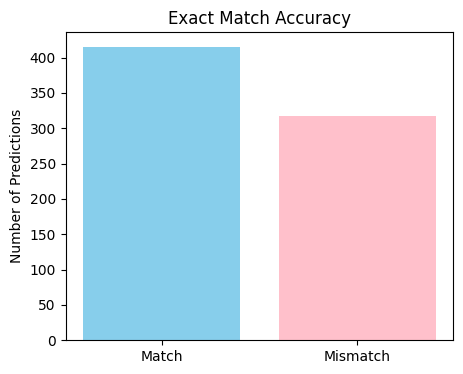

In [ ]:
# exact matches
match = (y_true == y_pred)
match_counts = match.value_counts()


plt.figure(figsize=(5, 4))
plt.bar(['Match', 'Mismatch'], match_counts, color=['skyblue', 'pink'])
plt.title("Exact Match Accuracy")
plt.ylabel("Number of Predictions")
plt.show()


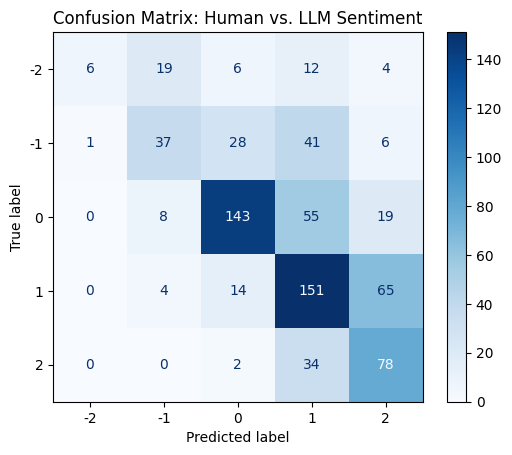

In [ ]:
y_true = df_O_merge["Human Classification"]
y_pred = df_O_merge["LLM Sentiment"]

labels = [-2, -1, 0, 1, 2]
cm = confusion_matrix(y_true, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Human vs. LLM Sentiment")
plt.show()


- row 1, column 2: 63 → Model predicted +2 instead of +1 (slight overestimation)

- row 0, column 1: 44 → Model predicted +1 instead of 0 (moderate overestimation)

- row 0, column 2: 21 → Model predicted +2 instead of 0 (strong overestimation)

- row -1, column 1: 31 → Model predicted +1 instead of -1 (mild reversal)

- row 2, column 1: 41 → Model predicted +1 instead of +2 (underestimation)

- row 2, column 2: 70 → Model correctly predicted +2 when the human label was +2

- row -2, column 0: 3 → Model correctly predicted -2

- row -2, column 1: 22 → Model predicted -1 instead of -2 (mild underestimation)

- row -2, column 2: 8 → Model predicted 0 instead of -2 (strong reversal)

In [ ]:
# False Negatives: LLM underestimates sentiment
false_negatives = df_O_merge[df_O_merge["LLM Sentiment"] < df_O_merge["Human Classification"]]

# False Positives: LLM overestimates sentiment
false_positives = df_O_merge[df_O_merge["LLM Sentiment"] > df_O_merge["Human Classification"]]

# Display results
print(f"False Negatives (LLM underestimated sentiment): {len(false_negatives)}")
print(false_negatives[["Paragraph Number", "Paragraph Text", "Human Classification", "LLM Sentiment"]].head())

print("\nFalse Positives (LLM overestimated sentiment):", len(false_positives))
print(false_positives[["Paragraph Number", "Paragraph Text", "Human Classification", "LLM Sentiment"]].head())

False Negatives (LLM underestimated sentiment): 63
    Paragraph Number                                     Paragraph Text  \
18                42  Prashanth Mahendra-Rajah Chief Financial Offic...   
31                60  More recently, BYD has committed to very, very...   
63               112  Dara Khosrowshahi Chief Executive Officer & Di...   
81               138  I'd also say that when we look at the category...   
86               143  And increasingly, we're working with merchants...   

    Human Classification  LLM Sentiment  
18                     2              1  
31                     2              1  
63                     1              0  
81                     1              0  
86                     2              1  

False Positives (LLM overestimated sentiment): 255
    Paragraph Number                                     Paragraph Text  \
4                 21  In fact, in Q2, the number of first-time consu...   
5                 22  We'll continue to driv

In [ ]:
false_negatives.to_excel("overall_Ordinal_fn.xlsx")

In [ ]:
false_positives.to_excel("overall_Ordinal_fp.xlsx")

<span style="color:hotpink;font-weight: bold; font-size: 20px;"> Metrics 4: Per-Class Metrics </span>

In [ ]:
print(classification_report(y_true, y_pred, labels=[-2, -1, 0, 1, 2]))


              precision    recall  f1-score   support

          -2       0.86      0.13      0.22        47
          -1       0.54      0.33      0.41       113
           0       0.74      0.64      0.68       225
           1       0.52      0.65      0.57       234
           2       0.45      0.68      0.55       114

    accuracy                           0.57       733
   macro avg       0.62      0.48      0.49       733
weighted avg       0.60      0.57      0.56       733



- overall Accuracy: 51% — the model correctly predicted sentiment in just over half the cases.

Best performance:

- Label 0 (neutral) had the highest precision (0.63) and recall (0.68), making it the most reliably predicted class.


struggles most with extremes:

- Label -2 (strongly negative) had very low recall (0.06), meaning the model rarely catches these cases.

- Label -1 also showed weak performance across all metrics, with an F1-score of just 0.34.

- Macro average F1-score is 0.42, showing weak performance across classes, especially the less frequent or more extreme sentiments.

- Weighted average F1-score is 0.49, indicating that even with class imbalance, the overall effectiveness is limited.


In [ ]:
# Create an empty dictionary to store the results
misclassifications = {}

# Loop through all possible combinations of true and predicted labels where they don't match
for true_label in [-2, -1, 0, 1, 2]:
    for pred_label in [-2, -1, 0, 1, 2]:
        if true_label != pred_label:
            key = f"True: {true_label}, Predicted: {pred_label}"
            filtered = df_O_merge[
                (df_O_merge["Human Classification"] == true_label) &
                (df_O_merge["LLM Sentiment"] == pred_label)
            ]
            misclassifications[key] = filtered

# Example: print a few key misclassifications
for key, df in misclassifications.items():
    print(f"\n{key} → {len(df)} samples")
    print(df[["Paragraph Number", "Paragraph Text", "Human Classification", "LLM Sentiment"]].head(3))



True: -2, Predicted: -1 → 19 samples
     Paragraph Number                                     Paragraph Text  \
50                 91  Justin Post Analyst, BofA Securities, Inc. Q T...   
119               237  So, overall, we're quite optimistic in terms o...   
134               263  Your comment on sort of where is Mobility head...   

     Human Classification  LLM Sentiment  
50                     -2             -1  
119                    -2             -1  
134                    -2             -1  

True: -2, Predicted: 0 → 6 samples
     Paragraph Number                                     Paragraph Text  \
260               479  Dara Khosrowshahi Chief Executive Officer & Di...   
281               509  In terms of AV, I think a couple of things in ...   
282               510  The operational domain for many of these AV de...   

     Human Classification  LLM Sentiment  
260                    -2              0  
281                    -2              0  
282            

In [ ]:
with pd.ExcelWriter("sentiment_misclassifications.xlsx") as writer:
    for key, df in misclassifications.items():
        # Sheet names can't be longer than 31 chars
        sheet_name = key.replace("True: ", "T").replace(", Predicted: ", "_P")
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)


In [ ]:
import pandas as pd

# FALSE POSITIVES: LLM overestimated sentiment
false_pos = df_O_merge[df_O_merge["LLM Sentiment"] > df_O_merge["Human Classification"]]

# FALSE NEGATIVES: LLM underestimated sentiment
false_neg = df_O_merge[df_O_merge["LLM Sentiment"] < df_O_merge["Human Classification"]]

# Function to export misclassifications into an Excel file
def export_misclassifications(df, filename):
    with pd.ExcelWriter(filename) as writer:
        for true_label in [-2, -1, 0, 1, 2]:
            for pred_label in [-2, -1, 0, 1, 2]:
                if pred_label != true_label:
                    subset = df[
                        (df["Human Classification"] == true_label) &
                        (df["LLM Sentiment"] == pred_label)
                    ]
                    if len(subset) > 0:
                        sheet_name = f"T{true_label}_P{pred_label}"
                        subset.to_excel(writer, sheet_name=sheet_name[:31], index=False)

# Export to two separate Excel files
export_misclassifications(false_pos, "all_FP_Sentiment.xlsx")
export_misclassifications(false_neg, "all_FN_Sentiment.xlsx")
